# New York Taxi Tiping Prediction: Yellow Taxi Dataset in 2009

In [1]:
import duckdb
import pandas as pd
from river import linear_model, preprocessing, metrics

In [2]:
query_yellow_2009 = """
WITH CTE_yellow_2009 AS (
    SELECT 
        CAST(Trip_Pickup_DateTime AS TIMESTAMP) AS pick_up_time,
        CAST(Trip_Dropoff_DateTime AS TIMESTAMP) AS drop_off_time,
        CAST(Passenger_Count AS INTEGER) AS passenger_count,
        CAST(Trip_Distance AS INTEGER) AS trip_distance,
        Payment_Type AS payment_type,
        CAST(Total_Amt AS FLOAT)   AS total_amount,
        Tip_Amt AS tip_amount,
        CAST(Tip_Amt AS FLOAT)   AS tip_amount,
        CAST( CASE Payment_Type
            WHEN  'Credit' THEN 1
            WHEN  'CREDIT' THEN 1
            ELSE 2
        END AS INTEGER) AS payment_category,
        CAST( CASE Tip_Amt
            WHEN  0.0 THEN 1
            ELSE 0
        END AS INTEGER) AS tip_category
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_*.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count >= 0
        AND Trip_Distance >= 0 
        AND Trip_Distance <= 50
        AND Payment_Type IS NOT NULL
        AND Total_Amt >= 0
        AND Tip_Amt >= 0
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-01-01'
), CTE_duration_yellow_2009 AS (
    SELECT
        pick_up_time,
        drop_off_time,
        passenger_count,
        trip_distance,
        total_amount,
        payment_category,
        tip_category,
        DATE_DIFF('day', pick_up_time, drop_off_time) AS duration_days,
        EPOCH(drop_off_time - pick_up_time) AS duration_seconds
    FROM CTE_yellow_2009
    WHERE payment_category = 1
)

SELECT 
    passenger_count,
    trip_distance,
    total_amount,
    CAST(duration_seconds AS FLOAT)   AS duration_seconds,
    tip_category
FROM CTE_duration_yellow_2009
WHERE duration_days = 0
"""

#con = duckdb.connect()
#df_yellow_2009 = con.execute(query_yellow_2009).fetchdf()
#df_yellow_2009.head()

## 1. Batching Dataset before Streaming 
Each batch will use 500000 rows.

In [3]:
# Connect to DuckDB
con = duckdb.connect("yellow_2009.duckdb")

# Example parameters
batch_size = 500_000
offset = 0

while True:
    df = con.execute(f"""
        {query_yellow_2009}
        LIMIT {batch_size} OFFSET {offset}
    """).fetchdf()

    if df.empty:
        break

    # process df here
    offset += batch_size

## 2. Logistic Regression for Classification
Use logistic regression as first try.

In [6]:
from river import linear_model, preprocessing, metrics

model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
metric = metrics.Accuracy()

for batch in con.execute(query_yellow_2009).fetch_record_batch():
    df = batch.to_pandas()

    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        metric.update(yi, y_pred)

    print("Processed batch, accuracy:", metric.get())

Processed batch, accuracy: 0.969352
Processed batch, accuracy: 0.969389
Processed batch, accuracy: 0.9695183333333334
Processed batch, accuracy: 0.9696045
Processed batch, accuracy: 0.969676
Processed batch, accuracy: 0.969718
Processed batch, accuracy: 0.9696707142857143
Processed batch, accuracy: 0.969594875
Processed batch, accuracy: 0.9695737777777778
Processed batch, accuracy: 0.9695547
Processed batch, accuracy: 0.9695495454545454
Processed batch, accuracy: 0.9695396666666667
Processed batch, accuracy: 0.9695428461538461
Processed batch, accuracy: 0.9695460714285714
Processed batch, accuracy: 0.9695593333333333
Processed batch, accuracy: 0.969560875
Processed batch, accuracy: 0.9695795882352941
Processed batch, accuracy: 0.9696272777777778
Processed batch, accuracy: 0.9696817368421052
Processed batch, accuracy: 0.9697211
Processed batch, accuracy: 0.9697284761904762
Processed batch, accuracy: 0.9697355
Processed batch, accuracy: 0.9697342173913044
Processed batch, accuracy: 0.969

## 3. Balance Accuracy with Logistic Regression
Since dataset highly imbalance, the accuracy metric is less accurate because model tend to predict the majority. For that reason, we can change the metric by focusing on balancing the imbalance dataset.

In [7]:
from river import linear_model, preprocessing, metrics

model = preprocessing.StandardScaler() | linear_model.LogisticRegression()
metric = metrics.BalancedAccuracy()   # better for imbalance

for batch in con.execute(query_yellow_2009).fetch_record_batch():
    df = batch.to_pandas()

    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        metric.update(yi, y_pred)

    print("Processed batch, balanced accuracy:", metric.get())


Processed batch, balanced accuracy: 0.5001508704244862
Processed batch, balanced accuracy: 0.5001902493027736
Processed batch, balanced accuracy: 0.5002146523773596
Processed batch, balanced accuracy: 0.5001856682632837
Processed batch, balanced accuracy: 0.5001685451341861
Processed batch, balanced accuracy: 0.5001634486078645
Processed batch, balanced accuracy: 0.5001777158014638
Processed batch, balanced accuracy: 0.5001902210855368
Processed batch, balanced accuracy: 0.5002270702429364
Processed batch, balanced accuracy: 0.5002261360223541
Processed batch, balanced accuracy: 0.5002170493212446
Processed batch, balanced accuracy: 0.5002151275709655
Processed batch, balanced accuracy: 0.5002024134647688
Processed batch, balanced accuracy: 0.500209309617351
Processed batch, balanced accuracy: 0.5002110089005969
Processed batch, balanced accuracy: 0.5002076659266773
Processed batch, balanced accuracy: 0.5002093394655317
Processed batch, balanced accuracy: 0.5002035632429928
Processed b

## 4. Tree Based Classifier for Imbalance Dataset
Try the tree based model that representative for imbalance dataset.

In [11]:
from river import tree, preprocessing, metrics

model = preprocessing.StandardScaler() | tree.HoeffdingTreeClassifier(
    grace_period=200,
    delta=1e-5,       # instead of split_confidence
    tau=0.05,         # tie threshold
    max_depth=10
)

metric = metrics.BalancedAccuracy()

for batch in con.execute(query_yellow_2009).fetch_record_batch():
    df = batch.to_pandas()

    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        metric.update(yi, y_pred)

    print("Processed batch, balanced accuracy:", metric.get())



Processed batch, balanced accuracy: 0.3465653759666514
Processed batch, balanced accuracy: 0.35102881393571456
Processed batch, balanced accuracy: 0.3525940190289015
Processed batch, balanced accuracy: 0.35383120108915106
Processed batch, balanced accuracy: 0.35535007066747526
Processed batch, balanced accuracy: 0.35601741556272076
Processed batch, balanced accuracy: 0.35666285717798685
Processed batch, balanced accuracy: 0.3563960058196987
Processed batch, balanced accuracy: 0.3561883507748245
Processed batch, balanced accuracy: 0.3564379135630134
Processed batch, balanced accuracy: 0.3566742301948722
Processed batch, balanced accuracy: 0.3565625308892881
Processed batch, balanced accuracy: 0.35648590058547786
Processed batch, balanced accuracy: 0.35656684376289016
Processed batch, balanced accuracy: 0.35666791395482816
Processed batch, balanced accuracy: 0.35676159768636423
Processed batch, balanced accuracy: 0.3568688596347245
Processed batch, balanced accuracy: 0.35687997248199066


Conclusion: the streaming process is succesfull. But the accuracy after balancing is around 0.5 (which is the same as random guessing). The tree based model has lower accuracy which is around 0.35 which is lower than random guessing. This will be the focus for next project, finding the accurate model that represent data properly.

In [18]:
from river import ensemble, metrics
from river.ensemble import ARFClassifier

# Adaptive Random Forest Classifier
model = ensemble.ARFClassifier(
    n_models=10,
    max_features='sqrt',
    lambda_value=6,
    seed=42
)

metric = metrics.BalancedAccuracy()

for batch in con.execute(query_yellow_2009).fetch_record_batch():
    df = batch.to_pandas()
    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        metric.update(yi, y_pred)

    print("Processed batch, balanced accuracy:", metric.get())



ImportError: cannot import name 'ARFClassifier' from 'river.ensemble' (C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\river\ensemble\__init__.py)

In [21]:
from river import ensemble
print(dir(ensemble))

['ADWINBaggingClassifier', 'ADWINBoostingClassifier', 'AdaBoostClassifier', 'BOLEClassifier', 'BaggingClassifier', 'BaggingRegressor', 'EWARegressor', 'LeveragingBaggingClassifier', 'SRPClassifier', 'SRPRegressor', 'StackingClassifier', 'VotingClassifier', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations', 'bagging', 'boosting', 'ewa', 'stacking', 'streaming_random_patches', 'voting']


In [23]:
from river import ensemble, tree, metrics

# Leveraging Bagging for streaming imbalanced data
model = ensemble.LeveragingBaggingClassifier(
    model=tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-7,
        max_depth=20
    ),
    n_models=10,
    w=6,       # Poisson resampling weight
    seed=42
)

metric = metrics.BalancedAccuracy()

for batch in con.execute(query_yellow_2009).fetch_record_batch():
    df = batch.to_pandas()
    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        metric.update(yi, y_pred)

    print("Processed batch, balanced accuracy:", metric.get())


Processed batch, balanced accuracy: 0.37349639222920267
Processed batch, balanced accuracy: 0.38889684485763865


KeyboardInterrupt: 

In [24]:
from river import ensemble, tree, metrics
import matplotlib.pyplot as plt
import pandas as pd

# Define model: Leveraging Bagging with Hoeffding Trees
model = ensemble.LeveragingBaggingClassifier(
    model=tree.HoeffdingTreeClassifier(
        grace_period=50,
        delta=1e-7,
        max_depth=20
    ),
    n_models=10,
    w=6,
    seed=42
)

# Track global + per-class metrics
balanced_acc = metrics.BalancedAccuracy()
report = metrics.ClassificationReport()

history = []

# Process batches
for i, batch in enumerate(con.execute(query_yellow_2009).fetch_record_batch()):
    df = batch.to_pandas()
    X = df.drop(columns=["tip_category"])
    y = df["tip_category"]

    for xi, yi in zip(X.to_dict(orient="records"), y):
        y_pred = model.predict_one(xi)
        model.learn_one(xi, yi)
        balanced_acc.update(yi, y_pred)
        report.update(yi, y_pred)

    # Save batch metrics
    history.append({
        "batch": i+1,
        "balanced_accuracy": balanced_acc.get(),
        **report.get()  # unpack per-class precision/recall/f1
    })

    print(f"\n=== After batch {i+1} ===")
    print("Balanced Accuracy:", balanced_acc.get())
    print(report)

# Convert to DataFrame for analysis
history_df = pd.DataFrame(history)

# Plot learning curve
plt.figure(figsize=(8,5))
plt.plot(history_df["batch"], history_df["balanced_accuracy"], marker="o")
plt.xlabel("Batch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy over Batches")
plt.grid(True)
plt.show()

# Display per-class evolution
display(history_df.head())  # first rows of metrics


NotImplementedError: 

Accuracy : 0.9817
Precision: 0.7675
Recall   : 0.5595
F1 Score : 0.6472


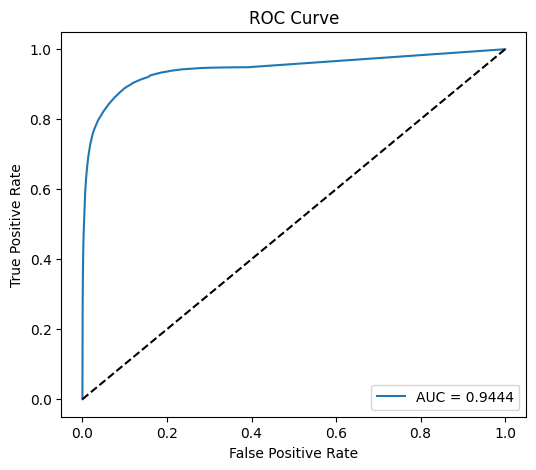

In [2]:
import duckdb
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
import matplotlib.pyplot as plt

# 1. Connect to DuckDB and load data
con = duckdb.connect("yellow_2009.duckdb")

query = """
WITH CTE_yellow_2009 AS (
    SELECT 
        CAST(Trip_Pickup_DateTime AS TIMESTAMP) AS pick_up_time,
        CAST(Trip_Dropoff_DateTime AS TIMESTAMP) AS drop_off_time,
        CAST(Passenger_Count AS INTEGER) AS passenger_count,
        CAST(Trip_Distance AS INTEGER) AS trip_distance,
        Payment_Type AS payment_type,
        CAST(Total_Amt AS FLOAT)   AS total_amount,
        Tip_Amt AS tip_amount,
        CAST(Tip_Amt AS FLOAT)   AS tip_amount,
        CAST( CASE Payment_Type
            WHEN  'Credit' THEN 1
            WHEN  'CREDIT' THEN 1
            ELSE 2
        END AS INTEGER) AS payment_category,
        CAST( CASE Tip_Amt
            WHEN  0.0 THEN 1
            ELSE 0
        END AS INTEGER) AS tip_category
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_*.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count >= 0
        AND Trip_Distance >= 0 
        AND Trip_Distance <= 50
        AND Payment_Type IS NOT NULL
        AND Total_Amt >= 0
        AND Tip_Amt >= 0
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-01-01'
), CTE_duration_yellow_2009 AS (
    SELECT
        pick_up_time,
        drop_off_time,
        passenger_count,
        trip_distance,
        total_amount,
        payment_category,
        tip_category,
        DATE_DIFF('day', pick_up_time, drop_off_time) AS duration_days,
        EPOCH(drop_off_time - pick_up_time) AS duration_seconds
    FROM CTE_yellow_2009
    WHERE payment_category = 1
)

SELECT 
    passenger_count,
    trip_distance,
    total_amount,
    CAST(duration_seconds AS FLOAT)   AS duration_seconds,
    tip_category
FROM CTE_duration_yellow_2009
WHERE duration_days = 0
"""
df = con.execute(query).fetchdf()   # Pandas DataFrame

# 2. Split features and target
X = df.drop(columns=["tip_category"])   # replace 'target' with your target column name
y = df["tip_category"]

# 3. Apply Tomek Links undersampling
tl = TomekLinks(sampling_strategy="auto")
X_res, y_res = tl.fit_resample(X, y)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

# 5. Train a classifier (Random Forest example)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# 6. Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probability for ROC

# 7. Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# 8. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
